## Preparation of Behavioral Data HCP

*This script was used to a) read in the behavioral data from the HCP, b) exclude subjects with missing data, c) split the sample into a main and a replication sample and d) analyze demographic data and neuroticism scores. Please note that the assessment of normality of neuroticism distributions was computed in the script: Plots_distribution_neuroticism_scores.*

### 1. Import Behavioral csv Files from HCP

*Change to desired directory*

In [84]:
import os 
print(os.getcwd())

os.chdir(r'E:\Data Project 4\Behavioral Data HCP')
print(os.getcwd())

E:\Data Project 4\Behavioral Data HCP
E:\Data Project 4\Behavioral Data HCP


In [86]:
import pandas as pd 

unrestricted_data = pd.read_csv(r'E:\Data Project 4\Behavioral Data HCP\unrestricted_johannapopp1_11_13_2024_9_1_37.csv')
restricted_data = pd.read_csv(r'E:\Data Project 4\Behavioral Data HCP\RESTRICTED_johannapopp1_11_13_2024_8_50_59.csv')

### 2. Combine both tables

In [88]:
HCP_behavioral_1206 = pd.merge(unrestricted_data, restricted_data, on = 'Subject', how = 'inner') #combine both tables

In [90]:
#print(HCP_behavioral_1206.head())
print(HCP_behavioral_1206.shape)

(1206, 782)


### 3. Only keep subjects from 7T release (the ones with movie data)

In [92]:
# there is one variable containing information whether the complete movie data exists
unique_values = HCP_behavioral_1206['fMRI_Movie_Compl'].unique()
print(unique_values)

[False  True]


*Create a new dataframe called HCP_behavioral_movie containing data from participants with movie data* 

In [94]:
# Only keep a dataframe with subjects that completed the scan

HCP_behavioral_movie = HCP_behavioral_1206[HCP_behavioral_1206['fMRI_Movie_Compl'] == True]
#save as csv file 
HCP_behavioral_movie.to_csv(r'E:\Data Project 4\Behavioral Data HCP\HCP_behavioral_movie.csv', index = False, encoding="utf-8")

# check wether this worked
print(HCP_behavioral_movie.shape)

(178, 782)


### 4. Check which subjects exist in MRI data folders but not in the behavioral data

In [96]:
import os

# Path with MRI Data 
mri_base_dir = r'E:\Data Project 4\nusregts_FIX2phys_noLP\nusregts_FIX2phys_noLP'

# List of folder names (Subjects in mri data)
mri_subjects = set(os.listdir(mri_base_dir))

# List subjects from behavioral data
behavioral_subjects = set(HCP_behavioral_movie['Subject'].astype(str))  # convert to string

# Subjects, that are only in behavioral data 
only_in_behavioral = behavioral_subjects - mri_subjects

# Subjects, that are only in MRI data
only_in_mri = mri_subjects - behavioral_subjects

# Results
print(f"Subjects in Behavioral but NOT in MRT: {len(only_in_behavioral)}")
print(only_in_behavioral)

print(f"Subjects in MRT but NOT in Behavioral: {len(only_in_mri)}")
print(only_in_mri)

Subjects in Behavioral but NOT in MRT: 0
set()
Subjects in MRT but NOT in Behavioral: 6
{'552241', '973770', '585256', '536647', '473952', '181636'}


**Information on Subject Exclusion**

*Checked the folders manually - these subjects indeed do not have all 4 movie scans completed*

*Also: No files found for '126931', '745555' - when reading in the fMRI data with the other script (probably some issues with Josh's preprocessing)*

### 5. Delete these two subjects from the HCP_behavioral_movie dataframe and save it to csv

In [99]:
# Check datatype for the  'Subject' collumn
print(HCP_behavioral_movie['Subject'].dtype)

int64


In [101]:
HCP_behavioral_movie_176 = HCP_behavioral_movie[~HCP_behavioral_movie['Subject'].isin([126931, 745555])]

In [103]:
HCP_behavioral_movie_176.shape

(176, 782)

In [105]:
HCP_behavioral_movie_176.to_csv(r'E:\Data Project 4\Behavioral Data HCP\HCP_behavioral_movie_176.csv', index = False, encoding="utf-8")

In [106]:
HCP_behavioral_movie_176["Family_ID"].nunique()

89

*There is one family with 4 members: Family 52938_82760: 146937; 346137; 401422; 942658*

In [109]:
family_counts = HCP_behavioral_movie_176["Family_ID"].value_counts()
families_with_3_or_more = family_counts[family_counts >= 3].index  # Liste der Family_IDs mit 3+ Einträgen

# Filter collumns belonging to this family
df_filtered = HCP_behavioral_movie_176[HCP_behavioral_movie_176["Family_ID"].isin(families_with_3_or_more)]

# Extraction of Family ID with Subject IDs belonging to it 
for family in families_with_3_or_more:
    subjects = df_filtered[df_filtered["Family_ID"] == family]["Subject"].tolist()
    print(f"Family {family}: {subjects}")


Family 52938_82760: [146937, 346137, 401422, 942658]


*Check whether this is true*

In [111]:
count = (HCP_behavioral_movie_176["Family_ID"] == "52938_82760").sum()
print(f"The entry '52938_82760' exists {count} times in column 'Family_ID'.")

The entry '52938_82760' exists 4 times in column 'Family_ID'.


*Two of these members have to be deleted (do not run this cell again or first selection will change!)*

In [157]:
#randomly select two values from this list
# import random

# values = [146937, 346137, 401422, 942658]
# random_selection = random.sample(values, 2)

# print(random_selection)

[146937, 401422]


*Delete these two subjects: [146937, 401422]*

In [115]:
HCP_behavioral_movie_174 = HCP_behavioral_movie_176[~HCP_behavioral_movie_176['Subject'].isin([146937,401422])]

In [117]:
HCP_behavioral_movie_174.shape

(174, 782)

*This is the final sample*

In [119]:
HCP_behavioral_movie_174.to_csv(r'E:\Data Project 4\Behavioral Data HCP\HCP_behavioral_movie_174.csv', index = False, encoding="utf-8")

### 6. Split into two samples (Separate families)

In [121]:
siblings_list = []
 
for family in HCP_behavioral_movie_174["Family_ID"].unique():
    siblings_list.append(HCP_behavioral_movie_174.query("Family_ID==@family").index.values)
 
print("There are {} unique families in the dataset".format(len(siblings_list)))
 
subj_set1 = [family[0] for family in siblings_list]
subj_set2 = [family[1] for family in siblings_list if len(family)>1]
 
# Make sure subjects are sorted
subj_set1.sort()
subj_set2.sort()
 
print("There are {} unrelated subjects in set 1".format(len(subj_set1)))
print("There are {} unrelated subjects in set 2".format(len(subj_set2)))

There are 89 unique families in the dataset
There are 89 unrelated subjects in set 1
There are 85 unrelated subjects in set 2


In [123]:
# Save subsamples as DataFrames 
sample_1 = HCP_behavioral_movie_174.loc[subj_set1].reset_index(drop=True)
sample_2 = HCP_behavioral_movie_174.loc[subj_set2].reset_index(drop=True)

*Define definition for stratified family split*

In [125]:
print(sample_1.shape)
print(sample_2.shape)

(89, 782)
(85, 782)


In [127]:
sample_1.to_csv(r'E:\Data Project 4\Behavioral Data HCP\HCP_behavioral_movie_main_89.csv', index = False, encoding="utf-8")
sample_2.to_csv(r'E:\Data Project 4\Behavioral Data HCP\HCP_behavioral_movie_replication_85.csv', index = False, encoding="utf-8")

*Perform tests to see whether it worked*

In [129]:
meanN_sample_1 = sample_1['NEOFAC_N'].mean()
meanN_sample_2 = sample_2['NEOFAC_N'].mean()

print(meanN_sample_1)
print(meanN_sample_2)

no_duplicates_sample_1 = not sample_1['Family_ID'].duplicated().any()
print(no_duplicates_sample_1)

n_unique_sample_1 = sample_1['Family_ID'].nunique()
print(n_unique_sample_1)

no_duplicates_sample_2 = not sample_2['Family_ID'].duplicated().any()
print(no_duplicates_sample_2)

n_unique_sample_2 = sample_2['Family_ID'].nunique()
print(n_unique_sample_2)

16.49438202247191
16.152941176470588
True
89
True
85


### 7. Plot Neuroticism Distribution

*Plot distribution of N-scores in Main sample (N = 89)*

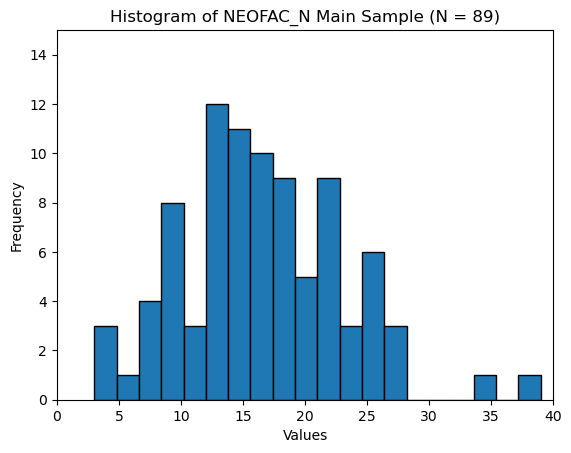

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram of a column named 'column_name'
plt.hist(sample_1['NEOFAC_N'], bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of NEOFAC_N Main Sample (N = 89)')

ax = plt.gca()
ax.set_xlim([0, 40])
ax.set_ylim([0, 15])

#Save plot 
plt.savefig("Distribution_N_Scores_Main.png", dpi=300, bbox_inches="tight") 

# Show the plot
plt.show()

*Plot distribution of N-scores in Replication sample (N = 85)*

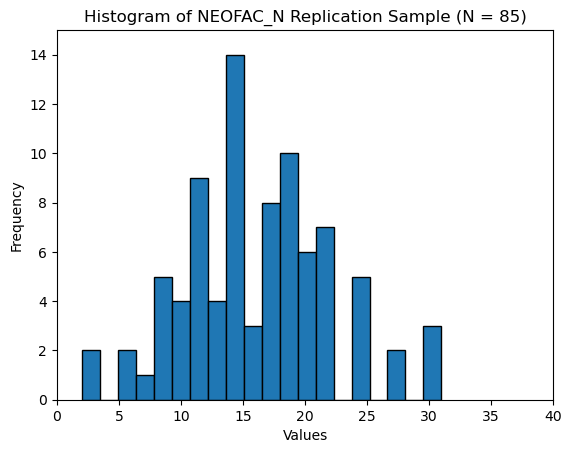

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram of a column named 'column_name'
plt.hist(sample_2['NEOFAC_N'], bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of NEOFAC_N Replication Sample (N = 85)')

ax = plt.gca()
ax.set_xlim([0, 40])
ax.set_ylim([0, 15])

#Save plot 
plt.savefig("Distribution_N_Scores_Replication.png", dpi=300, bbox_inches="tight") 

# Show the plot
plt.show()

*Plot distribution of N-scores in complete sample (N = 1206)*

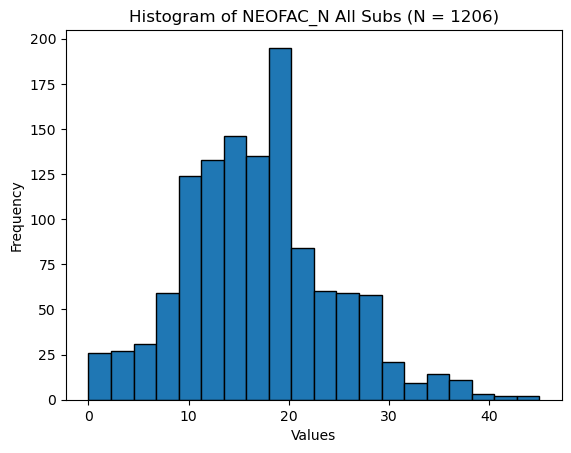

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram of a column named 'column_name'
plt.hist(HCP_behavioral_1206['NEOFAC_N'], bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of NEOFAC_N All Subs (N = 1206)')

# Show the plot
plt.show()


*Plot distribution of N-scores in complete movie sample (N = 174)*

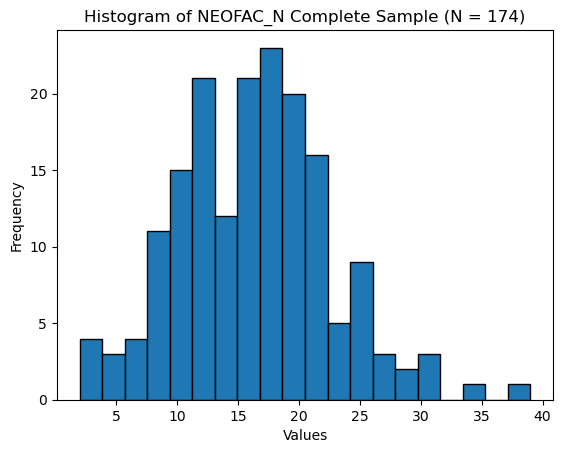

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram of a column named 'column_name'
plt.hist(HCP_behavioral_movie_174['NEOFAC_N'], bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of NEOFAC_N Complete Sample (N = 174)')

#Save plot 
plt.savefig("Distribution_N_Scores_Complete.png", dpi=300, bbox_inches="tight") 

# Show the plot
plt.show()


### 8. Get Sample Characteristics

*Complete Movie Sample*

In [135]:
mean_age = HCP_behavioral_movie_174['Age_in_Yrs'].mean()
std_age = HCP_behavioral_movie_174['Age_in_Yrs'].std()
max_age = HCP_behavioral_movie_174['Age_in_Yrs'].max()
min_age = HCP_behavioral_movie_174['Age_in_Yrs'].min()

print(mean_age)
print(std_age)
print(max_age)
print(min_age)

gender_counts = HCP_behavioral_movie_174['Gender'].value_counts()

print(f"Number of males (M): {gender_counts.get('M', 0)}")
print(f"number of females (F): {gender_counts.get('F', 0)}")

meanN_complete_sample = HCP_behavioral_movie_174['NEOFAC_N'].mean()
print(meanN_complete_sample)

29.304597701149426
3.2867366335761976
36
22
Number of males (M): 70
number of females (F): 104
16.32758620689655


*Main Sample*

In [137]:
mean_age = sample_1['Age_in_Yrs'].mean()
std_age = sample_1['Age_in_Yrs'].std()
max_age = sample_1['Age_in_Yrs'].max()
min_age = sample_1['Age_in_Yrs'].min()

print(mean_age)
print(std_age)
print(max_age)
print(min_age)

gender_counts = sample_1['Gender'].value_counts()

print(f"Number of males (M): {gender_counts.get('M', 0)}")
print(f"number of females (F): {gender_counts.get('F', 0)}")

meanN_main_sample = sample_1['NEOFAC_N'].mean()
print(meanN_main_sample)

29.382022471910112
3.3080673359968467
36
22
Number of males (M): 36
number of females (F): 53
16.49438202247191


*Replication Sample*

In [139]:
mean_age = sample_2['Age_in_Yrs'].mean()
std_age = sample_2['Age_in_Yrs'].std()
max_age = sample_2['Age_in_Yrs'].max()
min_age = sample_2['Age_in_Yrs'].min()

print(mean_age)
print(std_age)
print(max_age)
print(min_age)

gender_counts = sample_2['Gender'].value_counts()

print(f"Number of males (M): {gender_counts.get('M', 0)}")
print(f"number of females (F): {gender_counts.get('F', 0)}")

meanN_replication_sample = sample_2['NEOFAC_N'].mean()
print(meanN_replication_sample)

29.223529411764705
3.2819001123341547
36
22
Number of males (M): 34
number of females (F): 51
16.152941176470588
